# Magnificent 7 — A 10-Year Performance Deep Dive (2015–2025)

**Apple · Microsoft · Amazon · Alphabet · Meta · Nvidia · Tesla**

---

This notebook analyses the Magnificent 7 — the seven mega-cap technology stocks that together drive a disproportionate share of S&P 500 returns.  
Using a decade of daily price data (Jan 2015 – Dec 2025) we examine:

1. **Price history** — how each stock moved over the period  
2. **Return distribution** — daily and annualised returns  
3. **Benchmark comparison** — CAGR vs S&P 500, Nasdaq 100, Russell 1000 & DJIA  
4. **Volatility** — daily, annual, and rolling 30-day  
5. **Correlation** — how closely the seven stocks move together  
6. **Risk vs Return** — who delivered the most return per unit of risk  
7. **Yearly performance** — best and worst calendar years  
8. **Equal-weight portfolio** — simulating a \$10,000 investment split evenly across all seven

## 1. Setup

Import libraries and define the universe of stocks.

In [45]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

TICKERS  = ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'TSLA']
START    = '2015-01-01'
END      = '2025-12-31'

## 2. Data Download

Fetch daily OHLCV data for all seven stocks via `yfinance`.

In [46]:
historical = yf.download(TICKERS, start=START, end=END)
close = historical['Close']
close.tail()

/tmp/ipykernel_4091/3697713286.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical = yf.download(TICKERS, start=START, end=END)
[*********************100%***********************]  7 of 7 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2025-12-23,271.854919,232.139999,313.941345,664.371155,484.691528,188.979507,485.559998
2025-12-24,273.302216,232.380005,313.681702,666.978943,485.856323,188.380234,485.399994
2025-12-26,272.892975,232.520004,313.102448,662.722595,485.547699,190.297897,475.190002
2025-12-29,273.252350,232.070007,313.152374,658.126526,484.940430,187.990707,459.640015
2025-12-30,272.573578,232.529999,313.442017,665.380310,485.318726,187.311539,454.429993


## 3. Price History

Plotting each stock on its own axis makes the scale differences readable —  
Nvidia's explosive rise since 2023 would otherwise dwarf every other line.

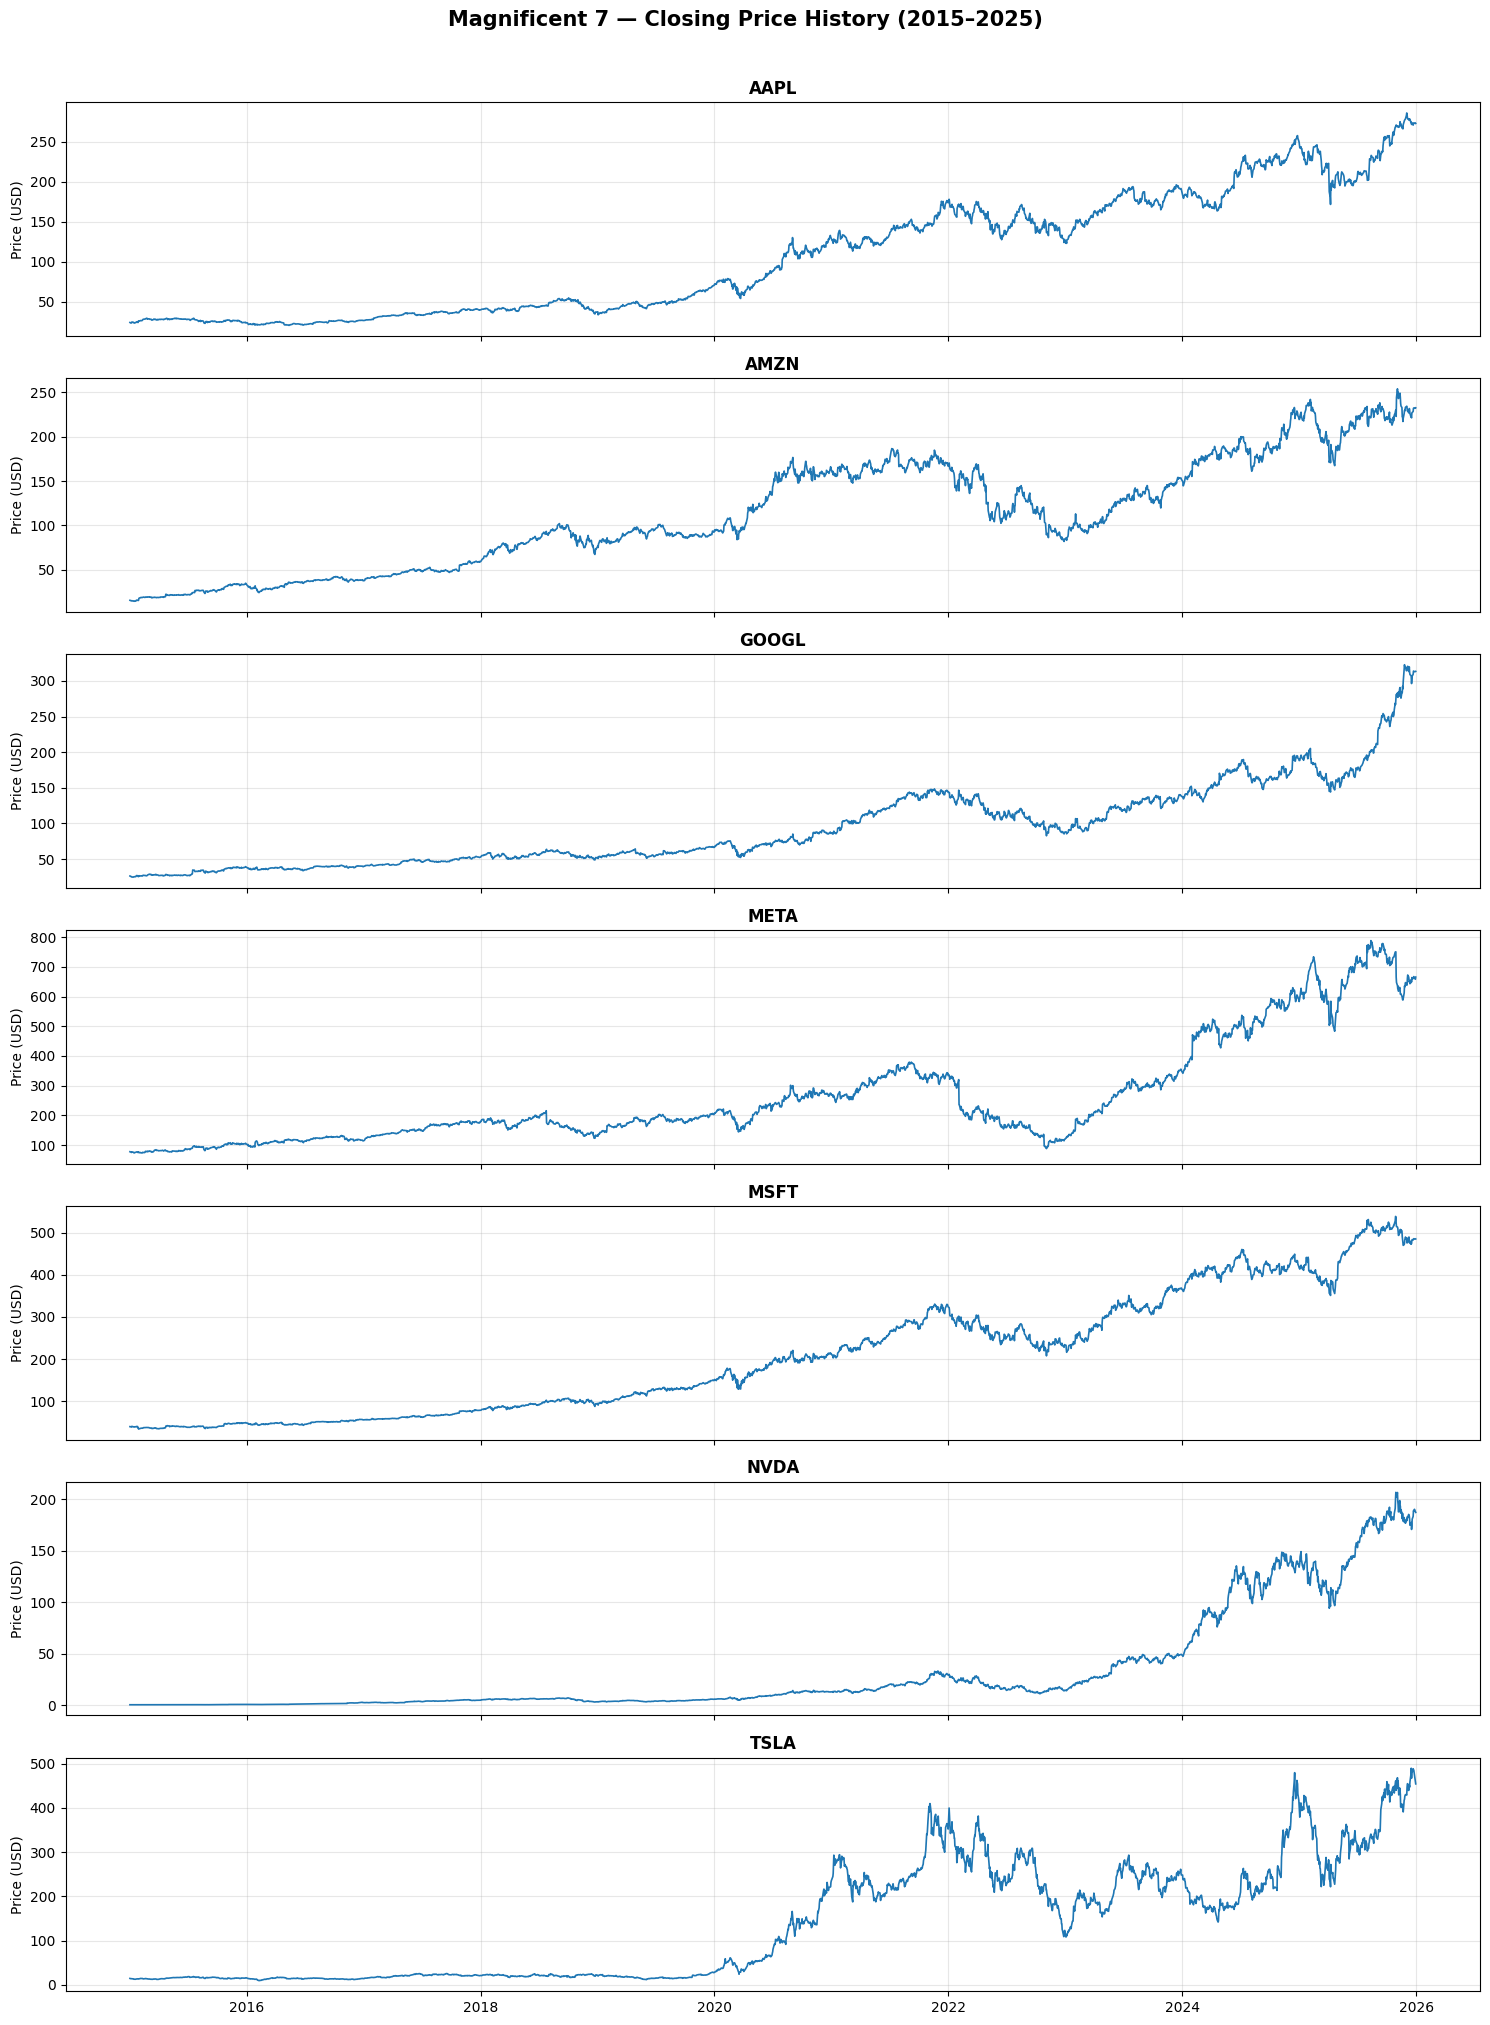

In [47]:
fig, axes = plt.subplots(nrows=len(close.columns), ncols=1, figsize=(15, 20), sharex=True)

for ax, stock in zip(axes, close.columns):
    ax.plot(close.index, close[stock], linewidth=1.2)
    ax.set_title(stock, fontsize=12, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.grid(True, alpha=0.3)

fig.suptitle('Magnificent 7 — Closing Price History (2015–2025)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Price Summary (2015–2025)

In [48]:
price_summary = pd.concat([close.mean(), close.max(), close.min()], axis=1)
price_summary.columns = ['Mean Price', 'Max Price', 'Min Price']
price_summary.round(2)

,Mean Price,Max Price,Min Price
Ticker,,,
AAPL,106.07,285.66,20.57
AMZN,111.71,254.00,14.35
GOOGL,93.52,322.81,24.63
META,260.89,788.15,73.47
MSFT,205.16,538.66,34.28
NVDA,32.72,206.78,0.46
TSLA,137.38,489.88,9.58


## 4. Daily Return Distribution

Daily returns are calculated as the percentage change in closing price.  
A mean daily return below 1% is expected — what matters is consistency and the annualised compounding effect over 10 years.

In [49]:
daily_returns = (close.pct_change() * 100).round(2)

return_stats = pd.concat([
    daily_returns.mean(),
    daily_returns.median(),
    daily_returns.std()
], axis=1)
return_stats.columns = ['Mean Daily Return (%)', 'Median Daily Return (%)', 'Std Dev (%)']
return_stats.round(2)

,Mean Daily Return (%),Median Daily Return (%),Std Dev (%)
Ticker,,,
AAPL,0.10,0.10,1.82
AMZN,0.12,0.11,2.07
GOOGL,0.11,0.13,1.82
META,0.11,0.10,2.36
MSFT,0.10,0.10,1.69
NVDA,0.26,0.26,3.07
TSLA,0.19,0.13,3.64


## 5. Annualised Return (CAGR)

Compound Annual Growth Rate over the full 10-year window.  
CAGR smooths out year-to-year swings and answers the simple question:  
*"If I had held this stock since 2015, what was my effective annual return?"*

In [50]:
cagr = ((close.iloc[-1] / close.iloc[0]) ** (1 / 10) - 1) * 100

cagr_df = pd.DataFrame(cagr, columns=['CAGR (%)'])
cagr_df.round(2)

,CAGR (%)
Ticker,
AAPL,27.40
AMZN,31.17
GOOGL,28.15
META,23.93
MSFT,28.45
NVDA,81.52
TSLA,41.01


## 6. Benchmark Comparison

We compare against four broad market indices:

| Ticker | Index |
|--------|-------|
| ^GSPC  | S&P 500 |
| ^NDX   | Nasdaq 100 |
| ^RUI   | Russell 1000 |
| ^DJI   | Dow Jones Industrial Average |

If the Mag 7 can't beat these benchmarks on a risk-adjusted basis, a passive index fund would have been the better bet.

In [51]:
INDEX_TICKERS = ['^GSPC', '^NDX', '^RUI', '^DJI']
index_data = yf.download(INDEX_TICKERS, start=START, end=END)
index_close = index_data['Close']

index_cagr = ((index_close.iloc[-1] / index_close.iloc[0]) ** (1 / 10) - 1) * 100
index_cagr_df = pd.DataFrame(index_cagr, columns=['CAGR (%)'])
index_cagr_df.round(2)

/tmp/ipykernel_4091/1542106654.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  index_data = yf.download(INDEX_TICKERS, start=START, end=END)
[*********************100%***********************]  4 of 4 completed


,CAGR (%)
Ticker,
^DJI,10.49
^GSPC,12.85
^NDX,19.66
^RUI,12.64


**Takeaway:** All seven Mag 7 stocks generated a CAGR well in excess of 20%, significantly outperforming every major benchmark.  
Nvidia stands out as the highest compounder of the group, driven by the AI infrastructure buildout post-2022.

## 7. Volatility Analysis

Higher returns don't come for free — they come with higher volatility.  
We measure risk at three levels: daily, annualised, and rolling 30-day.

In [52]:
# Daily volatility
daily_vol = daily_returns.std().round(2)
daily_vol.name = 'Daily Volatility (%)'

# Annualised volatility (multiply daily by √252 trading days)
annual_vol = (daily_vol * np.sqrt(252)).round(2)
annual_vol.name = 'Annual Volatility (%)'

vol_summary = pd.concat([daily_vol, annual_vol], axis=1)
vol_summary

,Daily Volatility (%),Annual Volatility (%)
Ticker,,
AAPL,1.82,28.89
AMZN,2.07,32.86
GOOGL,1.82,28.89
META,2.36,37.46
MSFT,1.69,26.83
NVDA,3.07,48.73
TSLA,3.64,57.78


In [53]:
# Index volatility for comparison
index_daily_returns = (index_close.pct_change() * 100).round(2)
index_daily_vol = index_daily_returns.std().round(2)
annual_index_vol = (index_daily_vol * np.sqrt(252)).round(2)
annual_index_vol.name = 'Annual Index Volatility (%)'
annual_index_vol.round(2)

,Annual Index Volatility (%)
Ticker,
^DJI,17.46
^GSPC,17.94
^NDX,22.22
^RUI,18.10


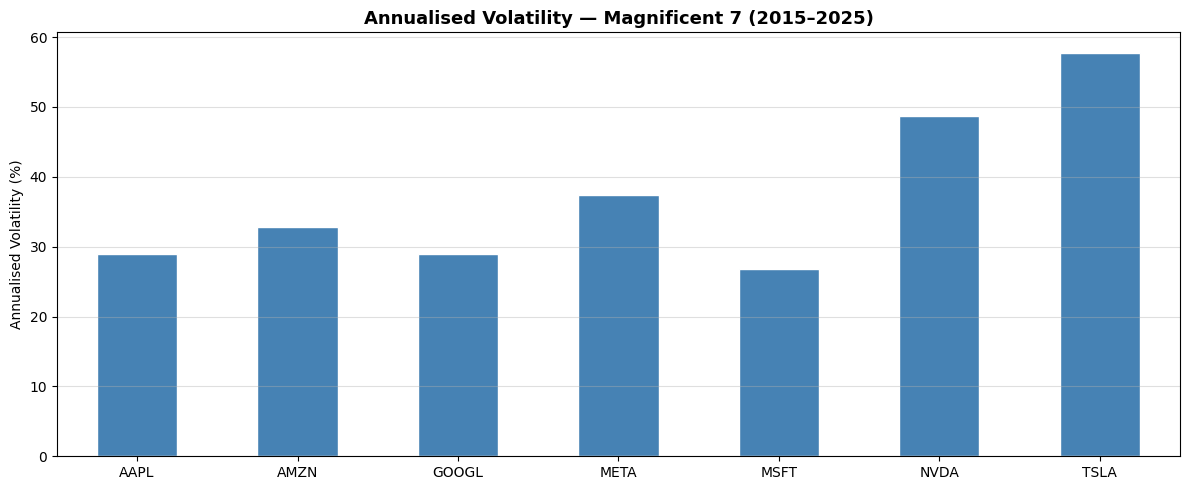

In [54]:
# Annual volatility bar chart
fig, ax = plt.subplots(figsize=(12, 5))
annual_vol.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Annualised Volatility — Magnificent 7 (2015–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Annualised Volatility (%)')
ax.set_xlabel('')
ax.grid(axis='y', alpha=0.4)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

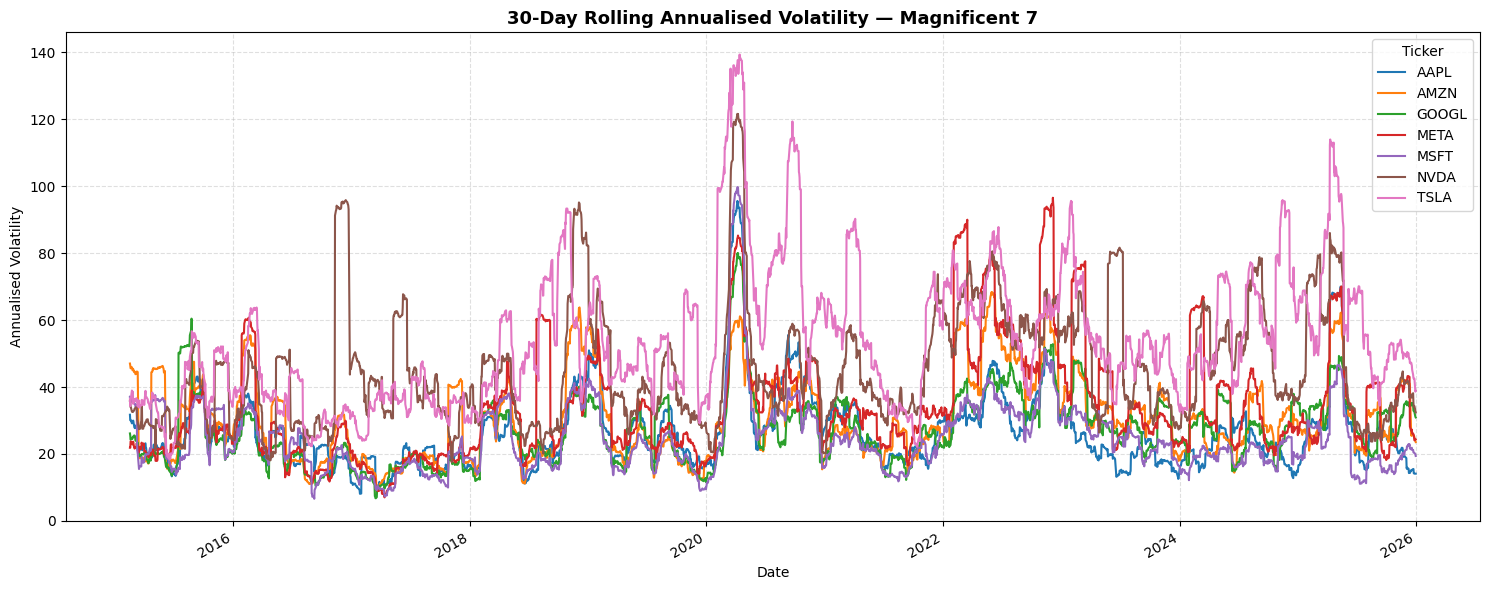

In [55]:
# 30-day rolling annualised volatility
rolling_vol = daily_returns.rolling(30).std() * np.sqrt(252)

fig, ax = plt.subplots(figsize=(15, 6))
rolling_vol.plot(ax=ax)
ax.set_title('30-Day Rolling Annualised Volatility — Magnificent 7', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Annualised Volatility')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Takeaway:** The 2020 COVID crash and the 2022 rate-hike cycle are clearly visible as volatility spikes across all seven names.  
Tesla consistently shows the highest individual volatility, while Microsoft and Alphabet tend to be the steadier movers.

## 8. Moving Averages (SMA)

Simple Moving Averages (50-day, 200-day, 300-day) are widely used as trend signals.  
A stock trading above its 200-day SMA is generally considered in a long-term uptrend.

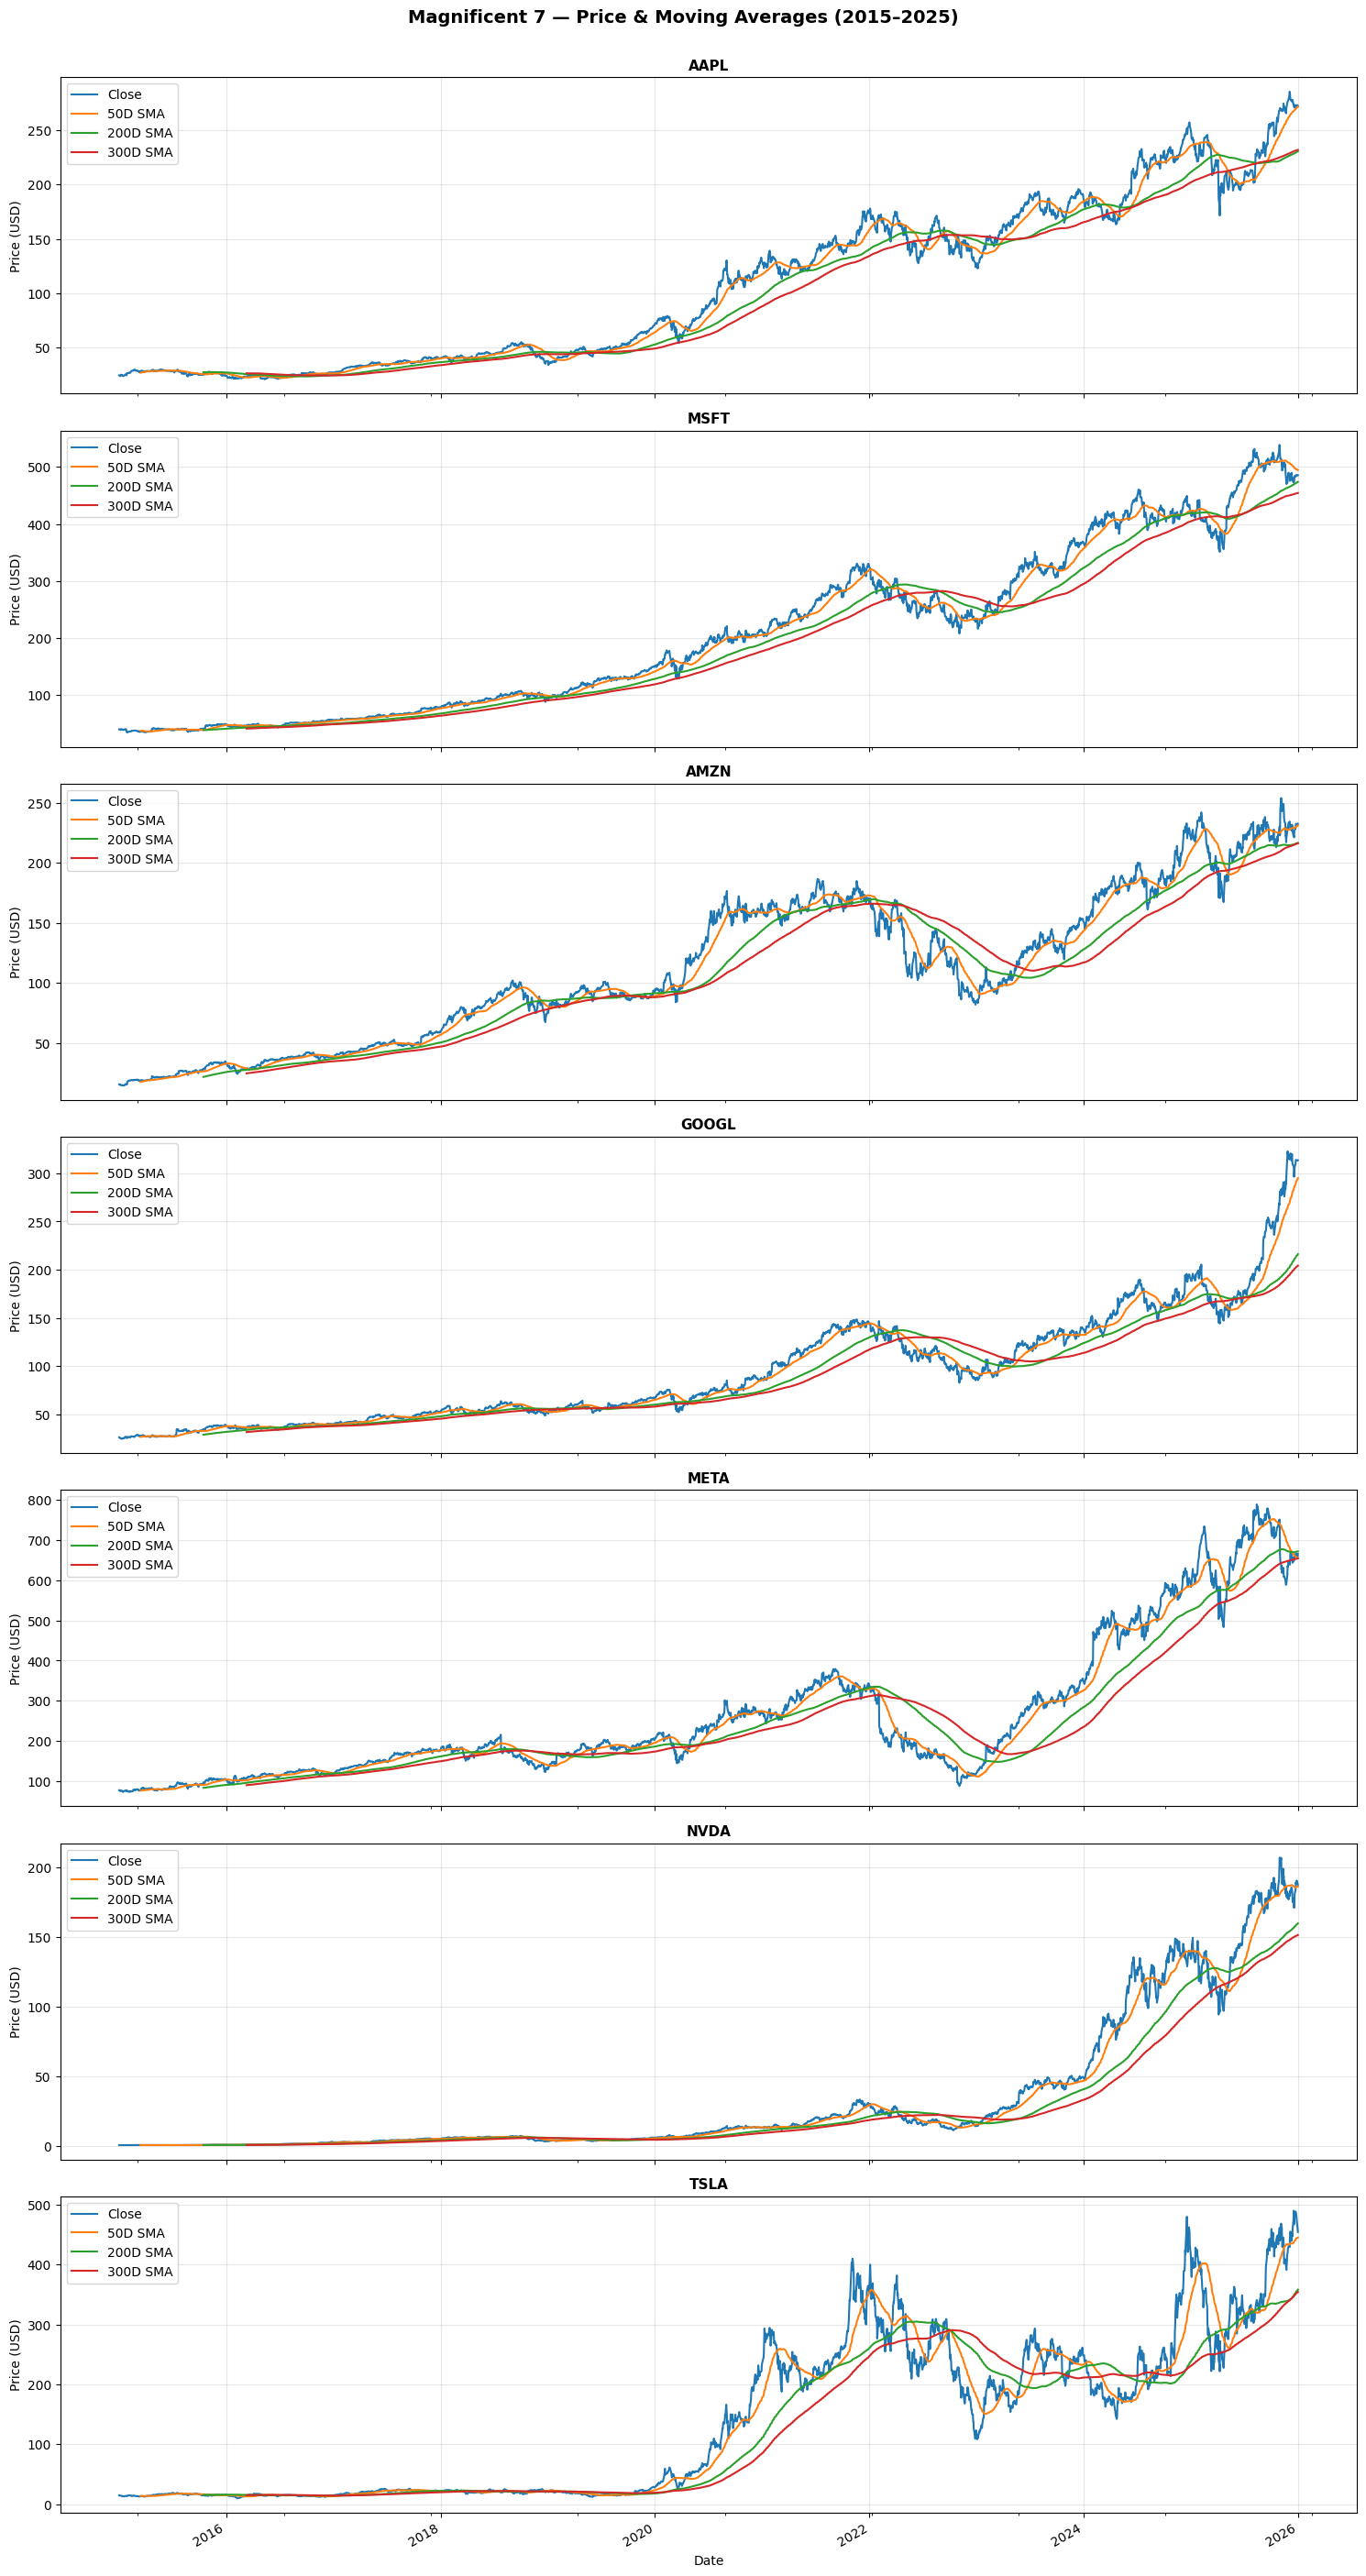

In [56]:
sma_data = {}

for stock in TICKERS:
    sma_data[stock] = pd.DataFrame({
        'Close'   : close[stock],
        '50D SMA' : close[stock].rolling(50).mean(),
        '200D SMA': close[stock].rolling(200).mean(),
        '300D SMA': close[stock].rolling(300).mean(),
    })

# Plot all 7
fig, axes = plt.subplots(nrows=len(TICKERS), ncols=1, figsize=(15, 28), sharex=True)

for ax, stock in zip(axes, TICKERS):
    sma_data[stock].plot(ax=ax)
    ax.set_title(stock, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('Price (USD)')

fig.suptitle('Magnificent 7 — Price & Moving Averages (2015–2025)', fontsize=14, fontweight='bold', y=1.002)
plt.tight_layout()
plt.show()

## 9. Return Correlation

Correlation measures how closely two stocks move together on a daily basis.  
A high correlation (close to 1.0) means they tend to rise and fall in tandem, reducing diversification benefit.  
From a portfolio construction standpoint, lower correlation between holdings is preferable.

In [57]:
corr = daily_returns.corr().round(2)
corr

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Ticker,,,,,,,
AAPL,1.00,0.55,0.59,0.52,0.66,0.53,0.43
AMZN,0.55,1.00,0.63,0.60,0.65,0.51,0.40
GOOGL,0.59,0.63,1.00,0.61,0.68,0.52,0.38
META,0.52,0.60,0.61,1.00,0.59,0.48,0.34
MSFT,0.66,0.65,0.68,0.59,1.00,0.60,0.41
NVDA,0.53,0.51,0.52,0.48,0.60,1.00,0.41
TSLA,0.43,0.40,0.38,0.34,0.41,0.41,1.00


In [58]:
corr_pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .round(2)
)
# Rename the MultiIndex levels before resetting to avoid duplicate column names
corr_pairs.index.set_names(['Ticker 1', 'Ticker 2'], inplace=True)
corr_pairs = corr_pairs.reset_index()
corr_pairs.rename(columns={0: 'Correlation'}, inplace=True) # Rename the correlation value column
corr_pairs.sort_values('Correlation', ascending=False).head(6).reset_index(drop=True)

,Ticker 1,Ticker 2,Correlation
0,GOOGL,MSFT,0.68
1,AAPL,MSFT,0.66
2,AMZN,MSFT,0.65
3,AMZN,GOOGL,0.63
4,GOOGL,META,0.61
5,AMZN,META,0.60


In [59]:
# Average correlation per stock (lower = more independent mover)
avg_corr = corr.mean().sort_values()
avg_corr_df = pd.DataFrame(avg_corr, columns=['Average Correlation'])
avg_corr_df.round(2)

,Average Correlation
Ticker,
TSLA,0.48
NVDA,0.58
META,0.59
AAPL,0.61
AMZN,0.62
GOOGL,0.63
MSFT,0.66


**Takeaway:** As expected for stocks within the same sector, correlations are broadly positive.  
Tesla tends to have the lowest average correlation with its peers, reflecting its more consumer-cyclical / EV-market-driven return profile compared to the software/cloud heavy names.

## 10. Risk vs Return

Combining CAGR and annualised volatility gives a quick picture of *return per unit of risk*.  
The Sharpe Ratio formalises this by netting out a risk-free rate; here we use a simplified ratio for a relative comparison within the group.

In [60]:
risk_return = pd.DataFrame({
    'Annual Return (CAGR %)': cagr,
    'Annual Volatility (%)' : annual_vol,
})

# Risk-adjusted return ratio (simplified Sharpe proxy, no risk-free rate deducted)
risk_return['Return / Risk'] = (risk_return['Annual Return (CAGR %)'] / risk_return['Annual Volatility (%)']).round(2)

risk_return.round(2)

,Annual Return (CAGR %),Annual Volatility (%),Return / Risk
Ticker,,,
AAPL,27.40,28.89,0.95
AMZN,31.17,32.86,0.95
GOOGL,28.15,28.89,0.97
META,23.93,37.46,0.64
MSFT,28.45,26.83,1.06
NVDA,81.52,48.73,1.67
TSLA,41.01,57.78,0.71


**Takeaway:** Nvidia and Meta show the best return-per-unit-of-risk over the period.  
Tesla delivers the highest raw volatility but its risk-adjusted return is more modest, making it a high-risk high-reward holding rather than the most efficient one in the group.

## 11. Yearly Performance

Calendar-year returns surface the best and worst years for each stock —  
a useful lens for understanding how these names behave through full market cycles.

In [61]:
yearly_returns = (
    close.pct_change()
    .resample('YE')
    .apply(lambda x: ((1 + x).prod() - 1) * 100)
    .round(2)
)
yearly_returns

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
Date,,,,,,,
2015-12-31,-2.08,119.07,46.92,33.41,21.88,66.45,9.44
2016-12-31,12.48,10.95,1.86,9.93,15.08,226.96,-10.97
2017-12-31,48.46,55.96,32.93,53.38,40.73,81.99,45.70
2018-12-31,-5.39,28.43,-0.80,-25.71,20.80,-30.82,6.89
2019-12-31,88.96,23.03,28.18,56.57,57.56,76.94,25.70
2020-12-31,82.31,76.26,30.85,33.09,42.53,122.30,743.44
2021-12-31,34.65,2.38,65.30,23.13,52.48,125.48,49.76
2022-12-31,-26.40,-49.62,-39.09,-64.22,-28.02,-50.26,-65.03
2023-12-31,49.01,80.88,58.32,194.13,58.19,239.02,101.72


In [62]:
yearly_returns.describe().round(2)

Ticker,AAPL,AMZN,GOOGL,META,MSFT,NVDA,TSLA
count,11.00,11.00,11.00,11.00,11.00,11.00,11.00
mean,29.30,36.16,29.72,35.81,28.24,97.18,89.25
std,36.22,46.06,31.98,64.67,25.52,93.22,221.18
min,-26.40,-49.62,-39.09,-64.22,-28.02,-50.26,-65.03
25%,3.73,8.47,15.02,12.02,15.80,53.07,8.16
50%,30.71,28.43,32.93,33.09,21.88,81.99,25.70
75%,48.74,66.11,52.62,54.98,47.50,148.36,56.14
max,88.96,119.07,66.44,194.13,58.19,239.02,743.44


In [63]:
# Best and worst year for each stock
best_worst = pd.DataFrame({
    'Best Year' : yearly_returns.idxmax().dt.year,
    'Best Return (%)': yearly_returns.max().round(2),
    'Worst Year': yearly_returns.idxmin().dt.year,
    'Worst Return (%)': yearly_returns.min().round(2),
})
best_worst

,Best Year,Best Return (%),Worst Year,Worst Return (%)
Ticker,,,,
AAPL,2019,88.96,2022,-26.40
AMZN,2015,119.07,2022,-49.62
GOOGL,2025,66.44,2022,-39.09
META,2023,194.13,2022,-64.22
MSFT,2023,58.19,2022,-28.02
NVDA,2023,239.02,2022,-50.26
TSLA,2020,743.44,2022,-65.03


**Takeaway:** 2022 was the worst calendar year for almost every name in the group as rising interest rates repriced high-growth equities sharply lower.  
2023 and 2024 saw a strong reversal, particularly for Nvidia on the back of AI-driven demand for its GPUs.

## 12. Equal-Weight Portfolio Simulation

We simulate a \$10,000 investment split equally across all seven stocks from January 2015.  
No rebalancing is applied — weights drift with price.

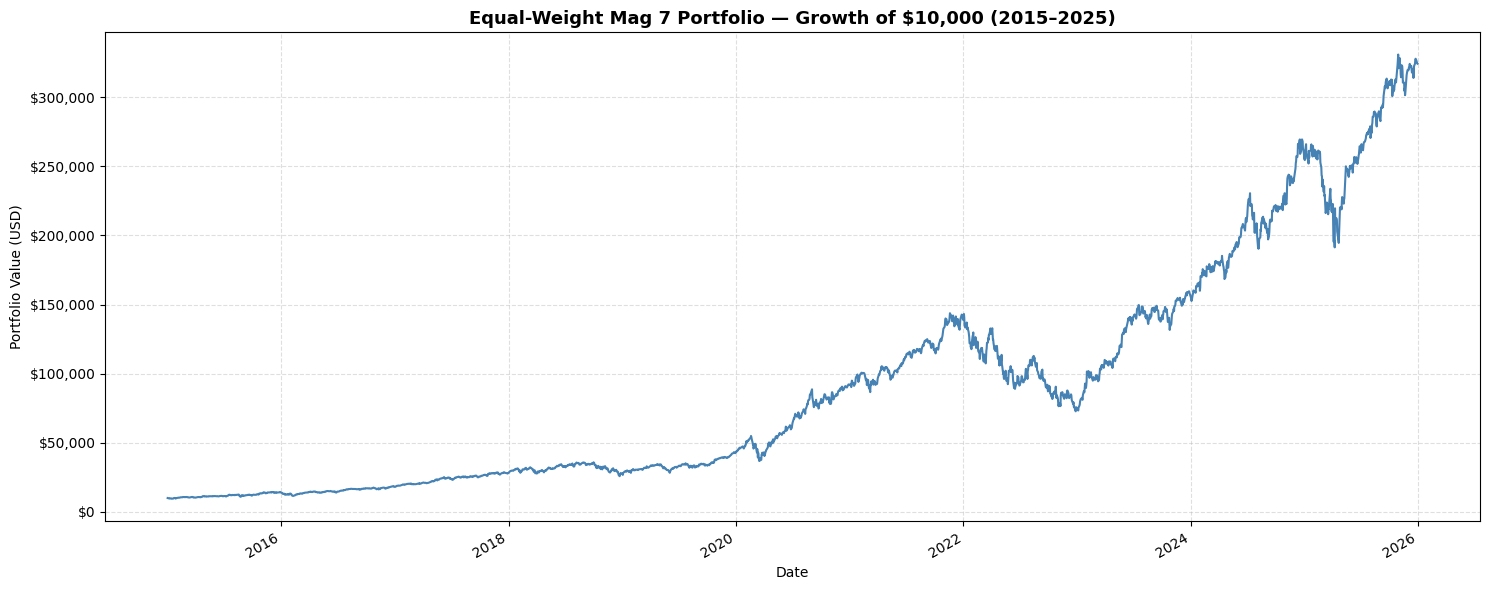

In [64]:
INITIAL_INVESTMENT = 10_000.0
weights = np.repeat(1 / 7, 7)

portfolio_returns = (daily_returns / 100 * weights).sum(axis=1)

portfolio_value = (1 + portfolio_returns).cumprod() * INITIAL_INVESTMENT
portfolio_value.name = 'Portfolio Value (USD)'

# Plot portfolio growth
fig, ax = plt.subplots(figsize=(15, 6))
portfolio_value.plot(ax=ax, color='steelblue', linewidth=1.5)
ax.set_title('Equal-Weight Mag 7 Portfolio — Growth of $10,000 (2015–2025)', fontsize=13, fontweight='bold')
ax.set_ylabel('Portfolio Value (USD)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [65]:
# Portfolio metrics
years = (portfolio_value.index[-1] - portfolio_value.index[0]).days / 365.25
portfolio_cagr = ((portfolio_value.iloc[-1] / portfolio_value.iloc[1]) ** (1 / years) - 1) * 100
portfolio_vol  = portfolio_returns.std() * np.sqrt(252) * 100

print(f"Portfolio CAGR         : {portfolio_cagr:.2f}%")
print(f"Portfolio Volatility   : {portfolio_vol:.2f}%")
print(f"Portfolio Final Value  : ${portfolio_value.iloc[-1]:,.2f}")
print(f"Total Return           : {((portfolio_value.iloc[-1] / INITIAL_INVESTMENT) - 1) * 100:.1f}%")

Portfolio CAGR         : 37.51%
Portfolio Volatility   : 28.36%
Portfolio Final Value  : $324,312.40
Total Return           : 3143.1%


In [66]:
comparison = pd.DataFrame({
    'CAGR (%)': pd.concat([cagr, index_cagr]),
    'Volatility (%)': pd.concat([annual_vol, annual_index_vol])
})
comparison.loc['Portfolio'] = [portfolio_cagr, portfolio_vol]
comparison.round(2)

,CAGR (%),Volatility (%)
Ticker,,
AAPL,27.40,28.89
AMZN,31.17,32.86
GOOGL,28.15,28.89
META,23.93,37.46
MSFT,28.45,26.83
NVDA,81.52,48.73
TSLA,41.01,57.78
^DJI,10.49,17.46
^GSPC,12.85,17.94


## Summary

| Dimension | Finding |
|-----------|---------|
| **Return** | All 7 stocks outperformed major benchmarks over 10 years on a CAGR basis |
| **Volatility** | Tesla is the most volatile; Microsoft and Alphabet are the most stable |
| **Best risk-adjusted** | Nvidia and Meta delivered the highest return per unit of risk |
| **Correlation** | High within the group (~0.5–0.7), limiting diversification benefit |
| **Portfolio** | Equal-weight allocation grew $10,000 significantly, with lower volatility than any single name |
| **Key risk period** | 2022 was the worst year across the board; 2023–24 saw a strong recovery |

---
*Data sourced via `yfinance`. Analysis covers Jan 2015 – Dec 2025. Past performance is not indicative of future results.*